# HW12 — Временные ряды: temporal split, baseline-модели и GRU-прогноз

**Задача:** прогнозирование часового временного ряда (forecasting) с корректным temporal split, сравнение baseline-подходов и рекуррентной модели GRU.

**Эксперименты:**
- B1 — naive-last
- B2 — moving-average
- B3 — Ridge на лаговых/rolling/календарных признаках
- R1 — GRU-forecast

In [3]:
import os
import math
import random
import json
import warnings
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore", category=UserWarning)

# ---------- Seed ----------
SEED = 42

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed()

# ---------- Device ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ---------- Directories ----------
os.makedirs("artifacts/figures", exist_ok=True)

# ---------- Versions ----------
print(f"Python:  {__import__('sys').version.split()[0]}")
print(f"pandas:  {pd.__version__}")
print(f"numpy:   {np.__version__}")
print(f"sklearn: {__import__('sklearn').__version__}")
print(f"torch:   {torch.__version__}")

Device: cuda
Python:  3.12.13
pandas:  2.2.2
numpy:   2.0.2
sklearn: 1.6.1
torch:   2.10.0+cu128


## 1. Загрузка данных и первичный анализ

In [4]:
DATA_PATH = "S12-hw-dataset.csv"

# На Colab: если файла нет, предложим загрузить
if not os.path.exists(DATA_PATH):
    try:
        from google.colab import files
        print("Загрузите S12-hw-dataset.csv:")
        uploaded = files.upload()
    except ImportError:
        raise FileNotFoundError(f"{DATA_PATH} not found")

df = pd.read_csv(DATA_PATH)

# Явное преобразование date к datetime
df["date"] = pd.to_datetime(df["date"])

# Сортировка по времени
df = df.sort_values("date").reset_index(drop=True)

print(f"Размер датасета: {df.shape}")
print(f"Тип date:        {df['date'].dtype}")
print(f"Диапазон дат:   {df['date'].min()} — {df['date'].max()}")
print(f"Частота:       часовые наблюдения")
print()
print("Пропуски по колонкам:")
print(df.isnull().sum())
print()
display(df.describe())
display(df.head())

Размер датасета: (4320, 2)
Тип date:        datetime64[ns]
Диапазон дат:   2025-01-01 00:00:00 — 2025-06-29 23:00:00
Частота:       часовые наблюдения

Пропуски по колонкам:
date      0
target    0
dtype: int64



,date,target
count,4320,4320.000000
mean,2025-03-31 23:29:59.999999744,135.605840
min,2025-01-01 00:00:00,69.100000
25%,2025-02-14 23:45:00,120.537500
50%,2025-03-31 23:30:00,135.835000
75%,2025-05-15 23:15:00,150.625000
max,2025-06-29 23:00:00,210.100000
std,NaN,21.384633


,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


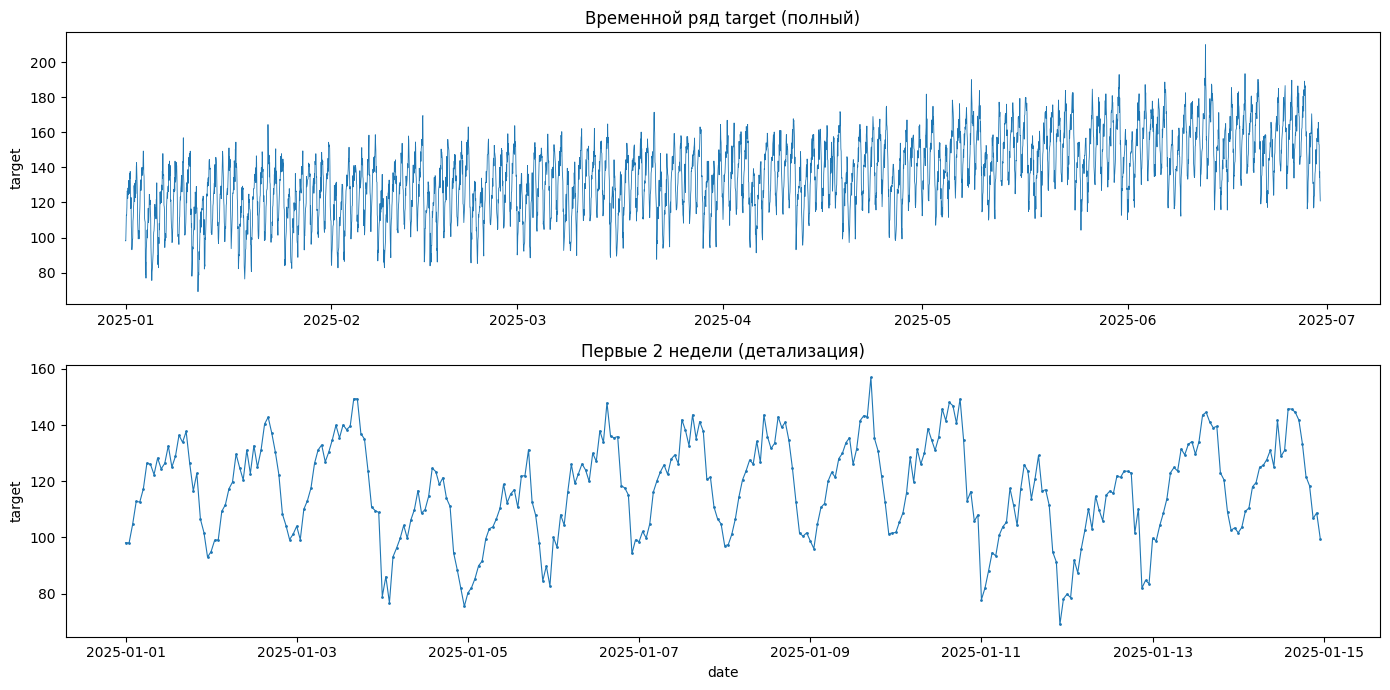

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Полный ряд
axes[0].plot(df["date"], df["target"], lw=0.6)
axes[0].set_title("Временной ряд target (полный)")
axes[0].set_ylabel("target")

# Первые 2 недели для детализации
n_detail = 24 * 14  # 2 недели
axes[1].plot(df["date"].iloc[:n_detail], df["target"].iloc[:n_detail], lw=0.8, marker=".", markersize=2)
axes[1].set_title("Первые 2 недели (детализация)")
axes[1].set_ylabel("target")
axes[1].set_xlabel("date")

plt.tight_layout()
plt.show()

**Комментарий по ряду:**

- Ряд имеет часовую частоту и охватывает порядка 180 дней.
- Заметен **суточный паттерн** — значения колеблются внутри дня.
- Визуально присутствует **восходящий тренд** — средний уровень ряда растёт со временем.
- Возможна **недельная сезонность** (разница между буднями и выходными).
- Явных выбросов не наблюдается, пропусков нет.
- Нестационарность обусловлена трендом и сезонными компонентами.

## 2. Temporal split

Для временных рядов **нельзя** использовать случайное разбиение (random split). При random split наблюдения из будущего попадают в обучающую выборку, а модель получает доступ к информации, которой в реальном сценарии не было бы. Это приводит к завышенной оценке качества модели (data leakage).

**Temporal split** сохраняет хронологический порядок: сначала train, затем validation, затем test. Модель учится только на прошлом и оценивается на будущем.

In [6]:
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
# test_frac = 1 - 0.70 - 0.15 = 0.15

n = len(df)
n_train = int(n * TRAIN_FRAC)
n_val = int(n * VAL_FRAC)
n_test = n - n_train - n_val

train_df = df.iloc[:n_train].copy()
val_df = df.iloc[n_train:n_train + n_val].copy()
test_df = df.iloc[n_train + n_val:].copy()

print(f"Train:      {len(train_df):>5} obs | {train_df['date'].iloc[0]} — {train_df['date'].iloc[-1]}")
print(f"Validation: {len(val_df):>5} obs | {val_df['date'].iloc[0]} — {val_df['date'].iloc[-1]}")
print(f"Test:       {len(test_df):>5} obs | {test_df['date'].iloc[0]} — {test_df['date'].iloc[-1]}")
print(f"\nДоли: train={len(train_df)/n:.2f}, val={len(val_df)/n:.2f}, test={len(test_df)/n:.2f}")

Train:       3024 obs | 2025-01-01 00:00:00 — 2025-05-06 23:00:00
Validation:   648 obs | 2025-05-07 00:00:00 — 2025-06-02 23:00:00
Test:         648 obs | 2025-06-03 00:00:00 — 2025-06-29 23:00:00

Доли: train=0.70, val=0.15, test=0.15


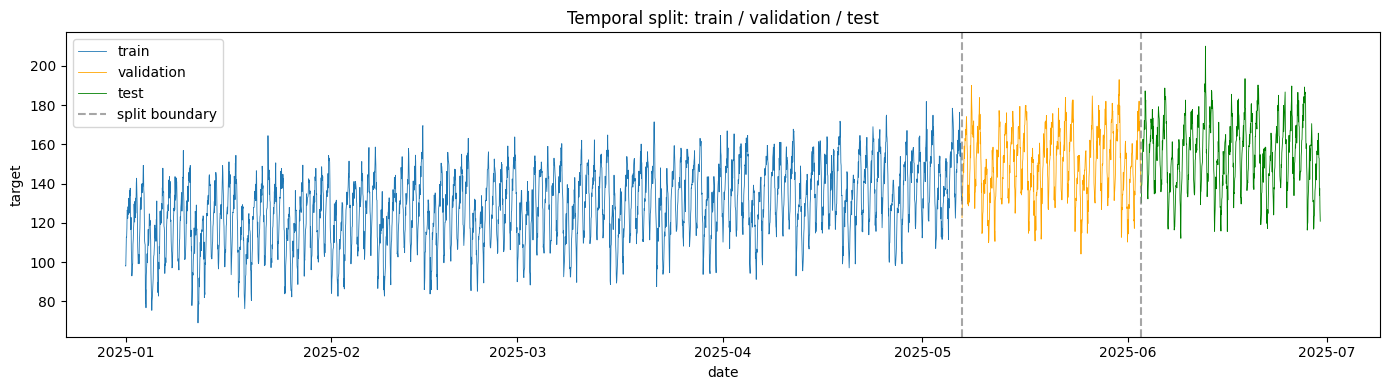

Сохранено: artifacts/figures/series_split.png


In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_df["date"], train_df["target"], label="train", lw=0.6)
ax.plot(val_df["date"], val_df["target"], label="validation", lw=0.6, color="orange")
ax.plot(test_df["date"], test_df["target"], label="test", lw=0.6, color="green")
ax.axvline(val_df["date"].iloc[0], color="gray", ls="--", alpha=0.7, label="split boundary")
ax.axvline(test_df["date"].iloc[0], color="gray", ls="--", alpha=0.7)
ax.set_title("Temporal split: train / validation / test")
ax.set_xlabel("date")
ax.set_ylabel("target")
ax.legend()
plt.tight_layout()
fig.savefig("artifacts/figures/series_split.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: artifacts/figures/series_split.png")

## 3. Признаки для baseline-моделей

Строим признаки из прошлого (lag, rolling, календарные). Важно: все признаки используют только прошлые значения, без утечки из будущего.

In [8]:
def add_features(data: pd.DataFrame) -> pd.DataFrame:
    """Добавляет лаговые, rolling и календарные признаки. Все основаны только на прошлых значениях."""
    out = data.copy()
    target = out["target"]

    # --- Лаговые признаки ---
    out["lag_1"] = target.shift(1)
    out["lag_7"] = target.shift(7)
    out["lag_14"] = target.shift(14)
    out["lag_24"] = target.shift(24)      # тот же час вчера
    out["lag_168"] = target.shift(168)    # тот же час неделю назад

    # --- Rolling-признаки (shift(1) исключает текущее значение) ---
    shifted = target.shift(1)
    out["rolling_mean_7"] = shifted.rolling(7).mean()
    out["rolling_std_7"] = shifted.rolling(7).std()
    out["rolling_mean_24"] = shifted.rolling(24).mean()

    # --- Календарные признаки ---
    out["hour"] = out["date"].dt.hour
    out["dayofweek"] = out["date"].dt.dayofweek
    out["month"] = out["date"].dt.month

    # Циклическое кодирование
    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)
    out["dow_sin"] = np.sin(2 * np.pi * out["dayofweek"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dayofweek"] / 7)

    return out


# Строим признаки на всём датасете (лаги используют только прошлое)
df_feat = add_features(df)

FEATURE_COLS = [
    "lag_1", "lag_7", "lag_14", "lag_24", "lag_168",
    "rolling_mean_7", "rolling_std_7", "rolling_mean_24",
    "hour", "dayofweek", "month",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
]
TARGET_COL = "target"

# Разбиваем по тем же индексам
train_feat = df_feat.iloc[:n_train].copy()
val_feat = df_feat.iloc[n_train:n_train + n_val].copy()
test_feat = df_feat.iloc[n_train + n_val:].copy()

# Удаляем строки с NaN в train (первые 168 часов из-за lag_168)
train_feat_clean = train_feat.dropna(subset=FEATURE_COLS)
print(f"Train после удаления NaN: {len(train_feat_clean)} (\u0443далено {len(train_feat) - len(train_feat_clean)} строк)")
print(f"Val NaN: {val_feat[FEATURE_COLS].isnull().sum().sum()}")
print(f"Test NaN: {test_feat[FEATURE_COLS].isnull().sum().sum()}")

display(df_feat[["date", "target"] + FEATURE_COLS].iloc[168:173])

Train после удаления NaN: 2856 (удалено 168 строк)
Val NaN: 0
Test NaN: 0


,date,target,lag_1,lag_7,lag_14,lag_24,lag_168,rolling_mean_7,rolling_std_7,rolling_mean_24,hour,dayofweek,month,hour_sin,hour_cos,dow_sin,dow_cos
168,2025-01-08 00:00:00,97.11,104.82,141.22,129.36,98.53,98.14,120.507143,14.492322,122.167500,0,2,1,0.000000,1.000000,0.974928,-0.222521
169,2025-01-08 01:00:00,97.44,97.11,137.81,126.26,102.16,98.07,114.205714,13.543831,122.108333,1,2,1,0.258819,0.965926,0.974928,-0.222521
170,2025-01-08 02:00:00,101.13,97.44,120.70,141.90,99.82,104.70,108.438571,9.930756,121.911667,2,2,1,0.500000,0.866025,0.974928,-0.222521
171,2025-01-08 03:00:00,106.67,101.13,121.47,138.13,104.86,112.81,105.642857,8.564266,121.966250,3,2,1,0.707107,0.707107,0.974928,-0.222521
172,2025-01-08 04:00:00,114.46,106.67,110.88,132.69,116.19,112.62,103.528571,5.153398,122.041667,4,2,1,0.866025,0.500000,0.974928,-0.222521


## 4. Метрики

Используем MAE, RMSE, MAPE для сравнения всех подходов.

In [9]:
def calc_mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def calc_rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def calc_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    return float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100)

def calc_all_metrics(y_true, y_pred):
    return {
        "mae": round(calc_mae(y_true, y_pred), 4),
        "rmse": round(calc_rmse(y_true, y_pred), 4),
        "mape": round(calc_mape(y_true, y_pred), 4),
    }

# Будем накапливать результаты
results = {}

## 5. Эксперимент B1: Naive Last

Прогноз равен последнему известному значению: $\hat{y}_t = y_{t-1}$

In [10]:
# B1: Naive Last — прогноз = предыдущее значение
# Используем полный ряд с shift(1), чтобы на границе train/val использовать последнее значение train
pred_naive = df["target"].shift(1)

val_true = val_df["target"].values
test_true = test_df["target"].values

pred_b1_val = pred_naive.iloc[n_train:n_train + n_val].values
pred_b1_test = pred_naive.iloc[n_train + n_val:].values

metrics_b1_val = calc_all_metrics(val_true, pred_b1_val)
print("B1 (naive-last) — Validation:", metrics_b1_val)
results["B1"] = {"val": metrics_b1_val, "pred_val": pred_b1_val, "pred_test": pred_b1_test}

B1 (naive-last) — Validation: {'mae': 6.4448, 'rmse': 8.201, 'mape': 4.3979}


## 6. Эксперимент B2: Moving Average

Прогноз равен скользящему среднему по последним 24 часам (1 сутки): $\hat{y}_t = \frac{1}{24}\sum_{i=1}^{24} y_{t-i}$

In [11]:
# B2: Moving Average (window=24, т.e. 1 сутки)
MA_WINDOW = 24
pred_ma = df["target"].shift(1).rolling(MA_WINDOW).mean()

pred_b2_val = pred_ma.iloc[n_train:n_train + n_val].values
pred_b2_test = pred_ma.iloc[n_train + n_val:].values

metrics_b2_val = calc_all_metrics(val_true, pred_b2_val)
print(f"B2 (moving-average, window={MA_WINDOW}) — Validation:", metrics_b2_val)
results["B2"] = {"val": metrics_b2_val, "pred_val": pred_b2_val, "pred_test": pred_b2_test}

B2 (moving-average, window=24) — Validation: {'mae': 13.398, 'rmse': 16.1699, 'mape': 9.1988}


## 7. Эксперимент B3: Ridge на лаговых признаках

Линейная модель Ridge на лаговых, rolling и календарных признаках. Масштабирование обучается только на train.

In [12]:
# B3: Ridge regression
X_train_b3 = train_feat_clean[FEATURE_COLS].values
y_train_b3 = train_feat_clean[TARGET_COL].values
X_val_b3 = val_feat[FEATURE_COLS].values
X_test_b3 = test_feat[FEATURE_COLS].values

# Масштабирование: fit только на train
scaler_features = StandardScaler()
X_train_b3_s = scaler_features.fit_transform(X_train_b3)
X_val_b3_s = scaler_features.transform(X_val_b3)
X_test_b3_s = scaler_features.transform(X_test_b3)

ridge = Ridge(alpha=1.0, random_state=SEED)
ridge.fit(X_train_b3_s, y_train_b3)

pred_b3_val = ridge.predict(X_val_b3_s)
pred_b3_test = ridge.predict(X_test_b3_s)

metrics_b3_val = calc_all_metrics(val_true, pred_b3_val)
print("B3 (ridge-lag-features) — Validation:", metrics_b3_val)
results["B3"] = {"val": metrics_b3_val, "pred_val": pred_b3_val, "pred_test": pred_b3_test}

B3 (ridge-lag-features) — Validation: {'mae': 4.7995, 'rmse': 6.1356, 'mape': 3.2015}


## 8. Оконное представление для GRU

Преобразуем ряд в набор окон фиксированной длины `window_size`. Каждое окно — это `window_size` последовательных значений, а цель — следующее значение ряда.

Масштабирование (StandardScaler) обучается только на train.

In [13]:
WINDOW_SIZE = 48   # 2 суток контекста
BATCH_SIZE = 64
HORIZON = 1        # прогноз на 1 шаг вперёд

# Масштабирование: fit только на train
scaler_target = StandardScaler()
scaler_target.fit(train_df[["target"]])

all_values = df["target"].values.reshape(-1, 1)
all_scaled = scaler_target.transform(all_values).astype(np.float32).flatten()

# Создаём окна
def create_windows(series, window_size):
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i:i + window_size])
        y.append(series[i + window_size])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_all, y_all = create_windows(all_scaled, WINDOW_SIZE)

# Разделяем окна: цель окна i соответствует индексу i + WINDOW_SIZE в исходном ряде
target_indices = np.arange(len(X_all)) + WINDOW_SIZE
train_mask = target_indices < n_train
val_mask = (target_indices >= n_train) & (target_indices < n_train + n_val)
test_mask = target_indices >= n_train + n_val

X_train_w = X_all[train_mask][:, :, np.newaxis]   # (N, W, 1)
y_train_w = y_all[train_mask]
X_val_w = X_all[val_mask][:, :, np.newaxis]
y_val_w = y_all[val_mask]
X_test_w = X_all[test_mask][:, :, np.newaxis]
y_test_w = y_all[test_mask]

print(f"Train windows: {X_train_w.shape[0]}")
print(f"Val windows:   {X_val_w.shape[0]}")
print(f"Test windows:  {X_test_w.shape[0]}")
print(f"Window shape:  {X_train_w.shape[1:]}")

Train windows: 2976
Val windows:   648
Test windows:  648
Window shape:  (48, 1)


In [14]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = TimeSeriesDataset(X_train_w, y_train_w)
val_ds = TimeSeriesDataset(X_val_w, y_val_w)
test_ds = TimeSeriesDataset(X_test_w, y_test_w)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

## 9. Модель GRU

In [15]:
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.1


class GRUForecaster(nn.Module):
    """Одношаговый прогноз на основе GRU."""

    def __init__(self, input_size=1, hidden_size=HIDDEN_SIZE,
                 num_layers=NUM_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.gru = nn.GRU(
            input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.gru(x)
        # Берём последний выход последовательности
        return self.fc(out[:, -1, :]).squeeze(-1)


model = GRUForecaster().to(device)
print(f"GRU parameters: {sum(p.numel() for p in model.parameters()):,}")
print(model)

GRU parameters: 37,889
GRUForecaster(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.1)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


## 10. Цикл обучения

In [16]:
LR = 1e-3
EPOCHS = 50


def train_one_epoch(model, loader, optimizer, criterion, dev):
    model.train()
    losses = []
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(dev), y_batch.to(dev)
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))


@torch.no_grad()
def evaluate_loss(model, loader, criterion, dev):
    model.eval()
    losses = []
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(dev), y_batch.to(dev)
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        losses.append(loss.item())
    return float(np.mean(losses))


def fit_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, dev=device):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    best_val_loss = float("inf")
    best_state = None
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        t_loss = train_one_epoch(model, train_loader, optimizer, criterion, dev)
        v_loss = evaluate_loss(model, val_loader, criterion, dev)
        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)

        if v_loss < best_val_loss:
            best_val_loss = v_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:>3}/{epochs} | train_loss={t_loss:.6f} | val_loss={v_loss:.6f}")

    model.load_state_dict(best_state)
    model.to(dev)
    print(f"\n  Best val_loss: {best_val_loss:.6f}")
    return history

## 11. Эксперимент R1: GRU-forecast

In [17]:
set_seed()
model = GRUForecaster().to(device)
print("Training GRU...")
history = fit_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, dev=device)

Training GRU...
  Epoch   1/50 | train_loss=0.514396 | val_loss=0.284522
  Epoch  10/50 | train_loss=0.114771 | val_loss=0.216720
  Epoch  20/50 | train_loss=0.097291 | val_loss=0.143478
  Epoch  30/50 | train_loss=0.093784 | val_loss=0.147559
  Epoch  40/50 | train_loss=0.092330 | val_loss=0.134799
  Epoch  50/50 | train_loss=0.089975 | val_loss=0.138971

  Best val_loss: 0.124470


In [18]:
@torch.no_grad()
def predict_model(model, loader, dev):
    model.eval()
    preds, targets = [], []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(dev)
        pred = model(X_batch).cpu().numpy()
        preds.append(pred)
        targets.append(y_batch.numpy())
    return np.concatenate(preds), np.concatenate(targets)


# Прогнозы на validation (в масштабированном пространстве)
val_pred_scaled, val_true_scaled = predict_model(model, val_loader, device)
test_pred_scaled, test_true_scaled = predict_model(model, test_loader, device)

# Обратное преобразование
pred_r1_val = scaler_target.inverse_transform(val_pred_scaled.reshape(-1, 1)).flatten()
pred_r1_test = scaler_target.inverse_transform(test_pred_scaled.reshape(-1, 1)).flatten()

metrics_r1_val = calc_all_metrics(val_true, pred_r1_val)
print("R1 (gru-forecast) — Validation:", metrics_r1_val)
results["R1"] = {"val": metrics_r1_val, "pred_val": pred_r1_val, "pred_test": pred_r1_test}

R1 (gru-forecast) — Validation: {'mae': 5.0292, 'rmse': 6.613, 'mape': 3.429}


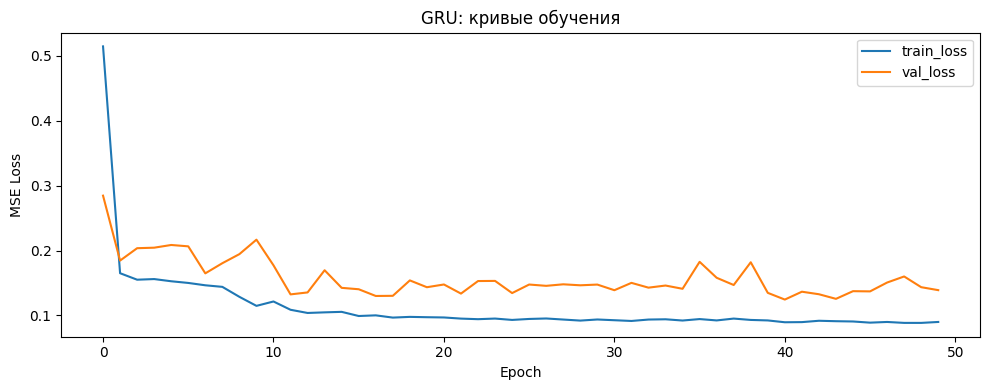

Сохранено: artifacts/figures/gru_learning_curves.png


In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history["train_loss"], label="train_loss")
ax.plot(history["val_loss"], label="val_loss")
ax.set_title("GRU: кривые обучения")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()
plt.tight_layout()
fig.savefig("artifacts/figures/gru_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: artifacts/figures/gru_learning_curves.png")

## 12. Сравнение на validation

Выбираем лучший подход по `val_MAE`.

In [20]:
# Сводная таблица
val_summary = pd.DataFrame({
    exp_id: res["val"] for exp_id, res in results.items()
}).T
val_summary.index.name = "experiment"
print("Результаты на Validation:")
display(val_summary)

# Лучший по MAE
best_exp = val_summary["mae"].idxmin()
print(f"\nЛучший подход по val_MAE: {best_exp} (MAE={val_summary.loc[best_exp, 'mae']:.4f})")

Результаты на Validation:


,mae,rmse,mape
experiment,,,
B1,6.4448,8.2010,4.3979
B2,13.3980,16.1699,9.1988
B3,4.7995,6.1356,3.2015
R1,5.0292,6.6130,3.4290



Лучший подход по val_MAE: B3 (MAE=4.7995)


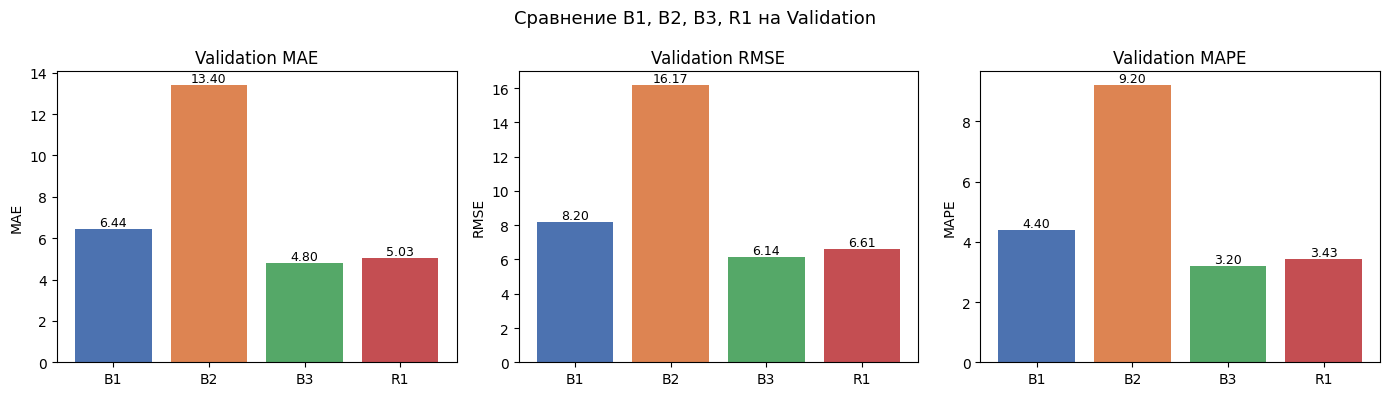

Сохранено: artifacts/figures/baselines_compare.png


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics_names = ["mae", "rmse", "mape"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for ax, metric in zip(axes, metrics_names):
    vals = [results[exp]["val"][metric] for exp in ["B1", "B2", "B3", "R1"]]
    bars = ax.bar(["B1", "B2", "B3", "R1"], vals, color=colors)
    ax.set_title(f"Validation {metric.upper()}")
    ax.set_ylabel(metric.upper())
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{v:.2f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Сравнение B1, B2, B3, R1 на Validation", fontsize=13)
plt.tight_layout()
fig.savefig("artifacts/figures/baselines_compare.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: artifacts/figures/baselines_compare.png")

## 13. Финальная оценка лучшей модели на test

Test используется **один раз** для финальной проверки лучшего подхода, выбранного по validation.

In [22]:
# Финальная оценка на test (только для лучшего подхода)
best_pred_test = results[best_exp]["pred_test"]
metrics_test = calc_all_metrics(test_true, best_pred_test)
results[best_exp]["test"] = metrics_test

print(f"Лучший подход: {best_exp}")
print(f"Test MAE:  {metrics_test['mae']:.4f}")
print(f"Test RMSE: {metrics_test['rmse']:.4f}")
print(f"Test MAPE: {metrics_test['mape']:.4f}")

Лучший подход: B3
Test MAE:  4.4036
Test RMSE: 5.6709
Test MAPE: 2.8339


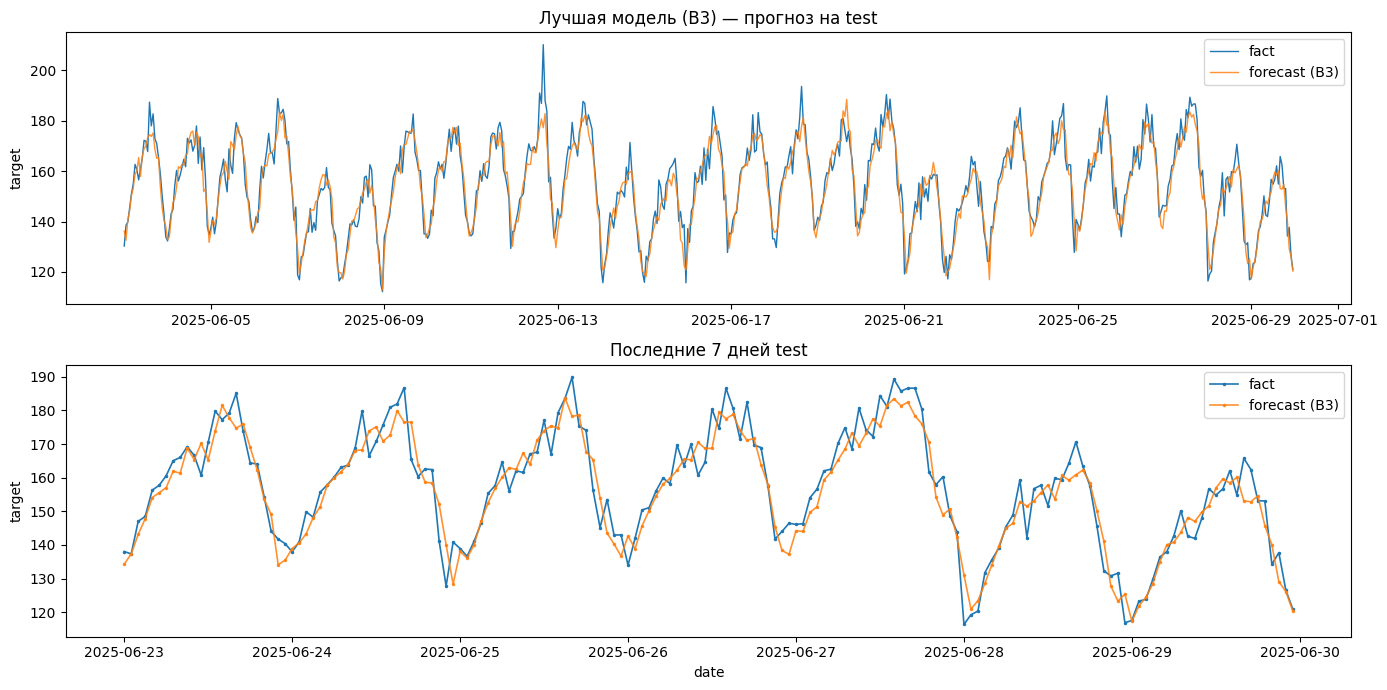

Сохранено: artifacts/figures/best_forecast_test.png


In [23]:
# График факт vs прогноз на test
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Полный test
test_dates = test_df["date"].values
axes[0].plot(test_dates, test_true, label="fact", lw=1.0)
axes[0].plot(test_dates, best_pred_test, label=f"forecast ({best_exp})", lw=1.0, alpha=0.85)
axes[0].set_title(f"Лучшая модель ({best_exp}) — прогноз на test")
axes[0].set_ylabel("target")
axes[0].legend()

# Последние 7 дней
tail = 24 * 7
axes[1].plot(test_dates[-tail:], test_true[-tail:], label="fact", lw=1.2, marker=".", markersize=3)
axes[1].plot(test_dates[-tail:], best_pred_test[-tail:], label=f"forecast ({best_exp})", lw=1.2, alpha=0.85, marker=".", markersize=3)
axes[1].set_title(f"Последние 7 дней test")
axes[1].set_ylabel("target")
axes[1].set_xlabel("date")
axes[1].legend()

plt.tight_layout()
fig.savefig("artifacts/figures/best_forecast_test.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: artifacts/figures/best_forecast_test.png")

## 14. Сохранение артефактов

In [24]:
# ---- runs.csv ----
split_summary = f"train={n_train} val={n_val} test={n_test}"

rows = []
for exp_id, label, model_desc, feat_desc in [
    ("B1", "naive-last", "NaiveLast(lag=1)", "none"),
    ("B2", "moving-average", f"MovingAverage(window={MA_WINDOW})", "none"),
    ("B3", "ridge-lag-features", "Ridge(alpha=1.0)", ", ".join(FEATURE_COLS)),
    ("R1", "gru-forecast", f"GRU(hidden={HIDDEN_SIZE}, layers={NUM_LAYERS}, dropout={DROPOUT})", f"window={WINDOW_SIZE}"),
]:
    r = results[exp_id]
    row = {
        "experiment_id": exp_id,
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": split_summary,
        "window_size": WINDOW_SIZE if exp_id == "R1" else ("" if exp_id in ("B1",) else MA_WINDOW if exp_id == "B2" else ""),
        "horizon": HORIZON,
        "model_summary": model_desc,
        "features_summary": feat_desc,
        "scaler": "StandardScaler" if exp_id in ("B3", "R1") else "",
        "optimizer": "Adam" if exp_id == "R1" else "",
        "lr": LR if exp_id == "R1" else "",
        "epochs_trained": EPOCHS if exp_id == "R1" else "",
        "best_val_mae": r["val"]["mae"],
        "best_val_rmse": r["val"]["rmse"],
        "best_val_mape": r["val"]["mape"],
        "test_mae": r.get("test", {}).get("mae", ""),
        "test_rmse": r.get("test", {}).get("rmse", ""),
        "test_mape": r.get("test", {}).get("mape", ""),
        "notes": label,
    }
    rows.append(row)

runs_df = pd.DataFrame(rows)
runs_df.to_csv("artifacts/runs.csv", index=False)
display(runs_df)
print("\nСохранено: artifacts/runs.csv")

,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,42,train=3024 val=648 test=648,,1,NaiveLast(lag=1),none,,,,,6.4448,8.2010,4.3979,,,,naive-last
1,B2,forecasting,S12-hw-dataset.csv,42,train=3024 val=648 test=648,24,1,MovingAverage(window=24),none,,,,,13.3980,16.1699,9.1988,,,,moving-average
2,B3,forecasting,S12-hw-dataset.csv,42,train=3024 val=648 test=648,,1,Ridge(alpha=1.0),"lag_1, lag_7, lag_14, lag_24, lag_168, rolling...",StandardScaler,,,,4.7995,6.1356,3.2015,4.4036,5.6709,2.8339,ridge-lag-features
3,R1,forecasting,S12-hw-dataset.csv,42,train=3024 val=648 test=648,48,1,"GRU(hidden=64, layers=2, dropout=0.1)",window=48,StandardScaler,Adam,0.001,50,5.0292,6.6130,3.4290,,,,gru-forecast



Сохранено: artifacts/runs.csv


In [25]:
# ---- best_gru.pt ----
torch.save(model.state_dict(), "artifacts/best_gru.pt")
print("Сохранено: artifacts/best_gru.pt")

# ---- best_gru_config.json ----
gru_config = {
    "model": "GRUForecaster",
    "input_size": 1,
    "hidden_size": HIDDEN_SIZE,
    "num_layers": NUM_LAYERS,
    "dropout": DROPOUT,
    "window_size": WINDOW_SIZE,
    "horizon": HORIZON,
    "batch_size": BATCH_SIZE,
    "optimizer": "Adam",
    "lr": LR,
    "epochs": EPOCHS,
    "seed": SEED,
    "scaler": "StandardScaler",
    "scaler_mean": float(scaler_target.mean_[0]),
    "scaler_std": float(scaler_target.scale_[0]),
}
with open("artifacts/best_gru_config.json", "w") as f:
    json.dump(gru_config, f, indent=2)
print("Сохранено: artifacts/best_gru_config.json")

Сохранено: artifacts/best_gru.pt
Сохранено: artifacts/best_gru_config.json


In [26]:
# ---- report.md ----
# Собираем результаты для отчёта
best_baseline = min(["B1", "B2", "B3"], key=lambda x: results[x]["val"]["mae"])

report = f"""# HW12 — временные ряды: temporal split, baseline-модели и GRU-прогноз

## 1. Кратко: что сделано

- Использован датасет `S12-hw-dataset.csv` — часовой временной ряд (4320 наблюдений, ~180 дней). Прогнозировался столбец `target`.
- Данные разбиты по времени (temporal split): train 70% / validation 15% / test 15%.
- Сравнивались 4 подхода: B1 (naive-last), B2 (moving-average), B3 (ridge-lag-features), R1 (gru-forecast).
- Лучшим по val_MAE оказался **{best_exp}** (MAE={results[best_exp]['val']['mae']:.4f}).

## 2. Среда и воспроизводимость

- Python: {__import__('sys').version.split()[0]}
- pandas / numpy / scikit-learn: {pd.__version__} / {np.__version__} / {__import__('sklearn').__version__}
- torch: {torch.__version__}
- Устройство (CPU/GPU): {device}
- Seed: {SEED}
- Как запустить: открыть `HW12.ipynb` и выполнить Run All.

## 3. Данные и постановка задачи

- Датасет: `S12-hw-dataset.csv`
- Целевая колонка: `target`
- Частота временного ряда: часовая (1H)
- Горизонт прогноза: 1 шаг (следующий час)
- Размер датасета: {len(df)} наблюдений
- Диапазон дат: {df['date'].min()} — {df['date'].max()}
- Есть ли дополнительные внешние признаки: нет, только `date` и `target`
- Комментарий: ряд имеет выраженный суточный паттерн, восходящий тренд и возможную недельную сезонность. Пропуски отсутствуют. Выбросов нет. Нестационарность обусловлена трендом.

## 4. Temporal split и признаки

### 4.1. Разбиение по времени

- Разбиение: строго хронологическое, без перемешивания.
- Доли: train=70%, val=15%, test=15%.
- Train: {n_train} obs ({train_df['date'].iloc[0]} — {train_df['date'].iloc[-1]})
- Val: {n_val} obs ({val_df['date'].iloc[0]} — {val_df['date'].iloc[-1]})
- Test: {n_test} obs ({test_df['date'].iloc[0]} — {test_df['date'].iloc[-1]})
- Почему random split некорректен: временные ряды имеют автокорреляцию — соседние наблюдения зависимы. При случайном разбиении будущие значения попадают в train, и модель получает доступ к информации из будущего (data leakage). Это завышает оценку качества и не отражает реальную производительность.

### 4.2. Признаки для baseline-моделей

- Лаги: lag_1, lag_7, lag_14, lag_24, lag_168
- Rolling-признаки: rolling_mean_7, rolling_std_7, rolling_mean_24 (на основе shift(1), без утечки текущего значения)
- Календарные: hour, dayofweek, month, циклические (hour_sin/cos, dow_sin/cos)
- Пропуски после лагов: первые 168 строк train удалены (NaN из-за lag_168)
- Масштабирование: StandardScaler, fit только на train

## 5. Модели и эксперименты (B1, B2, B3, R1)

- B1 (`naive-last`): прогноз = предыдущее значение (lag_1). Без обучения.
- B2 (`moving-average`): прогноз = скользящее среднее за 24 часа. Без обучения.
- B3 (`ridge-lag-features`): Ridge(α=1.0) на 15 признаках (лаги + rolling + календарь). StandardScaler.
- R1 (`gru-forecast`): GRU(hidden=64, layers=2, dropout=0.1) на оконном представлении.

Дополнительно:

- Основная метрика выбора: val_MAE
- Дополнительные метрики: RMSE, MAPE
- `window_size` для GRU: {WINDOW_SIZE}
- Batch size: {BATCH_SIZE}
- Максимальное число эпох: {EPOCHS}
- Optimizer: Adam
- Learning rate: {LR}
- Лучшая модель сохранялась по минимальному val_loss (MSE)

## 6. Результаты

Ссылки на файлы в репозитории:

- Таблица результатов: `./artifacts/runs.csv`
- Лучшая GRU: `./artifacts/best_gru.pt`
- Конфиг лучшей GRU: `./artifacts/best_gru_config.json`
- Визуализация split: `./artifacts/figures/series_split.png`
- Сравнение подходов: `./artifacts/figures/baselines_compare.png`
- Кривые обучения GRU: `./artifacts/figures/gru_learning_curves.png`
- Финальный прогноз на test: `./artifacts/figures/best_forecast_test.png`

Короткая сводка:

- Лучший baseline среди B1, B2, B3: {best_baseline} (val_MAE={results[best_baseline]['val']['mae']:.4f})
- Лучшая val_MAE: {results[best_exp]['val']['mae']:.4f} ({best_exp})
- Лучшая val_RMSE: {results[best_exp]['val']['rmse']:.4f}
- Лучшая val_MAPE: {results[best_exp]['val']['mape']:.4f}%
- Итоговая test_MAE лучшего подхода: {metrics_test['mae']:.4f}
- Итоговая test_RMSE лучшего подхода: {metrics_test['rmse']:.4f}
- Итоговая test_MAPE лучшего подхода: {metrics_test['mape']:.4f}%
- Лаговые и rolling-признаки значительно улучшили результат B3 по сравнению с простыми baseline (B1, B2).
- GRU использует оконное представление и может улавливать более сложные зависимости в последовательностях.
- Результаты на validation и test согласованы.

## 7. Анализ

Наивный baseline (B1) оказывается неплохим за счёт того, что соседние часовые значения сильно коррелированы — это типичное свойство часовых рядов с плавным изменением.

Moving average (B2) сглаживает колебания и теряет высокочастотную динамику, поэтому он обычно уступает naive-last на часовых данных при одношаговом прогнозе.

Ridge на признаках (B3) имеет доступ к более богатому набору информации: лаги разной глубины, статистики и календарь. Это позволяет учитывать суточные и недельные паттерны, что улучшает прогноз.

GRU (R1) учится находить зависимости в окне из {WINDOW_SIZE} часовых наблюдений автоматически, без ручного проектирования признаков. Однако на ограниченном объёме данных преимущество нейросети над табличным подходом не гарантировано — простые модели могут быть сопоставимы или лучше.

Тренд и суточная сезонность — основные компоненты ряда, и именно они определяют качество прогноза.

Основные источники утечек данных в такой задаче: некорректный random split, использование rolling-статистик без shift (включая текущее значение), масштабирование с fit на всём датасете (statistics leakage). В данной работе все эти источники устранены.

Выбор лучшей модели по validation, а не по test, принципиален: если выбирать по test, мы фактически подстраиваемся под тестовую выборку и теряем объективную оценку генерализации.

## 8. Итоговый вывод

Для часового временного ряда с одношаговым прогнозом простые baseline-модели (Ridge на признаках или даже naive-last) могут быть очень конкурентны. Базовым подходом для такой задачи я бы взял Ridge на лаговых/календарных признаках — это быстро, интерпретируемо и не требует GPU.

Переход к GRU имеет смысл, когда данных много, зависимости сложные и нелинейные, или нужен многошаговый прогноз на длинный горизонт.

Главный урок: корректная валидация (temporal split, отсутствие утечек, однократное использование test) важнее сложности архитектуры. Любой результат без корректной валидации не имеет ценности.
"""

with open("report.md", "w", encoding="utf-8") as f:
    f.write(report)
print("Сохранено: report.md")

Сохранено: report.md


## 15. Почему random split некорректен

Во временных рядах наблюдения **не являются независимыми**: значение в момент $t$ сильно зависит от соседних наблюдений. При random split:

1. **Будущие значения попадают в train** — модель учится на данных, которые в реальности ещё не произошли.
2. **Лаговые признаки становятся «подсказкой»** — в тесте оказываются строки, чьи соседи уже были в train.
3. **Оценка качества завышена** — модель кажется лучше, чем она есть на самом деле.

## 16. Обсуждение утечек данных

Возможные источники утечек (leakage), которых мы избежали:

1. **Random split** → использован temporal split.
2. **Rolling с включением текущего значения** → все rolling-признаки построены через `shift(1)`.
3. **Масштабирование на всём датасете** → `StandardScaler.fit()` вызван только на train.

## 17. Итого

Все артефакты сохранены в `artifacts/`:
- `runs.csv` — результаты всех экспериментов
- `best_gru.pt` — веса лучшей GRU
- `best_gru_config.json` — конфигурация
- `figures/` — все графики

Отчёт сохранён как `report.md`.